In [1]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

from pyproj import Transformer


In [2]:
import folium

In [3]:
import UBNA_localize_process_GCC__20250505 as localize

In [4]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*0.WAV'))
all_sync_wav_files = list(experiment_folder.glob('STF_*/2026*PYTHON_SYNC.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_sync_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_003000.WAV'),


In [5]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [6]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [7]:
photo_dir = Path.home() / "Downloads/audiomoth50_fencepost_pics"
photo_paths = sorted(photo_dir.rglob("*.HEIC"))

photo_metadata = []
if len(photo_paths) > 0:
    photo_metadata = json.loads(subprocess.check_output(["exiftool", "-json", "-n", *[str(path) for path in photo_paths]], text=True))

photo_marker_locations = []
for photo_metadata_row in photo_metadata:
    if "GPSLatitude" in photo_metadata_row and "GPSLongitude" in photo_metadata_row:
        photo_name = Path(photo_metadata_row["SourceFile"]).parent.name
        photo_location = [photo_metadata_row["GPSLatitude"], photo_metadata_row["GPSLongitude"]]
        photo_marker_locations.append((photo_name, photo_location, "lime"))

measurement_csv_path = photo_dir / "post_A7/Raw Data.csv"
measurement_marker_locations = []
if measurement_csv_path.exists():
    measurement_points = pd.read_csv(measurement_csv_path)
    measurement_points = measurement_points[int(len(measurement_points) * (0.4)):int(len(measurement_points) * (0.6))]
    measurement_points = measurement_points[["Latitude (°)", "Longitude (°)"]].dropna().copy()
    for measurement_row_i, measurement_row in measurement_points.iterrows():
        measurement_name = measurement_csv_path.parent.name
        measurement_location = [measurement_row["Latitude (°)"], measurement_row["Longitude (°)"]]
        measurement_marker_locations.append((measurement_name, measurement_location, "magenta"))

marker_locations = photo_marker_locations + measurement_marker_locations

   13 image files read


In [8]:
post_order = ["post_A7", "post_A1", "post_A4", "post_E2", "post_E4", "post_E8", "post_E9"]

post_points = pd.DataFrame([{"post": name, "lat": location[0], "lon": location[1]}
                            for name, location, fill_color in marker_locations
                            if name in post_order])

missing_posts = [post_name for post_name in post_order if post_name not in set(post_points["post"])]
if len(missing_posts) > 0:
    raise ValueError(f"Missing post points for: {missing_posts}")

average_post_locations = post_points.groupby("post")[["lat", "lon"]].mean().loc[post_order]
average_post_locations

,lat,lon
post,,
post_A7,47.655097,-122.296698
post_A1,47.655707,-122.296649
post_A4,47.655381,-122.296653
post_E2,47.654839,-122.295539
post_E4,47.654944,-122.294883
post_E8,47.654442,-122.294875
post_E9,47.654286,-122.295294


In [9]:
A_locs_mat_tdoa = np.array([np.concatenate([average_post_locations.loc['post_E4'].values, [7.5]]),
                            np.concatenate([average_post_locations.loc['post_E8'].values, [7.5]]),
                            np.concatenate([average_post_locations.loc['post_E9'].values, [7.5]])])
ref_A_loc = np.concatenate([average_post_locations.loc['post_E2'].values, [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65494444, -122.29488333,    7.5       ],
        [  47.65444167, -122.294875  ,    7.5       ],
        [  47.65428611, -122.29529444,    7.5       ]]),
 array([  47.65483889, -122.29553889,    7.5       ]))

In [10]:
# WGS84 longitude/latitude/elevation -> ECEF XYZ meters.
# always_xy=True means transform(lon, lat, height), even though EPSG:4979's
# formal axis order is lat, lon, height.
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

In [11]:
def latlon_delta_xy_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat0 = (lat1 + lat2) / 2
    dx = R * np.radians(lon2 - lon1) * np.cos(np.radians(lat0))
    dy = R * np.radians(lat2 - lat1)
    return dx, dy

In [12]:
A_locs_mat_tdoa_meters = np.zeros(A_locs_mat_tdoa.shape)
for channel_num in range(3):
    coords = A_locs_mat_tdoa[channel_num]
    x, y = latlon_delta_xy_m(ref_A_loc[0], ref_A_loc[1], coords[0], coords[1])
    A_locs_mat_tdoa_meters[channel_num] = np.array([x, y, (ref_A_loc[2] - coords[2])])

In [13]:
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_meters[:,:2]
ref_A_loc_meters = np.array([0, 0])
NUM_NONREFCHANNELS = 3

x0 = ref_A_loc_meters[0]
y0 = ref_A_loc_meters[1]

xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))

In [14]:
A_locs_mat_tdoa_meters

array([[ 49.10130981,  11.73724225],
       [ 49.72571837, -44.16909586],
       [ 18.30907842, -61.46608445]])

In [15]:
FREQ_UPPER_LIM = 2/8

In [17]:
valid_sync_wav_files = []
for wav_file in all_sync_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S_PYTHON_SYNC.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 20, 30, 0):
        valid_sync_wav_files += [wav_file]
valid_sync_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_027/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_060/20260604_203000_PYTHON_SYNC.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_113/20260604_203000_PYTHON_SYNC.WAV')]

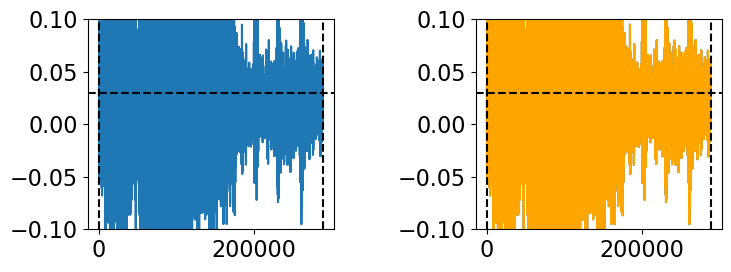

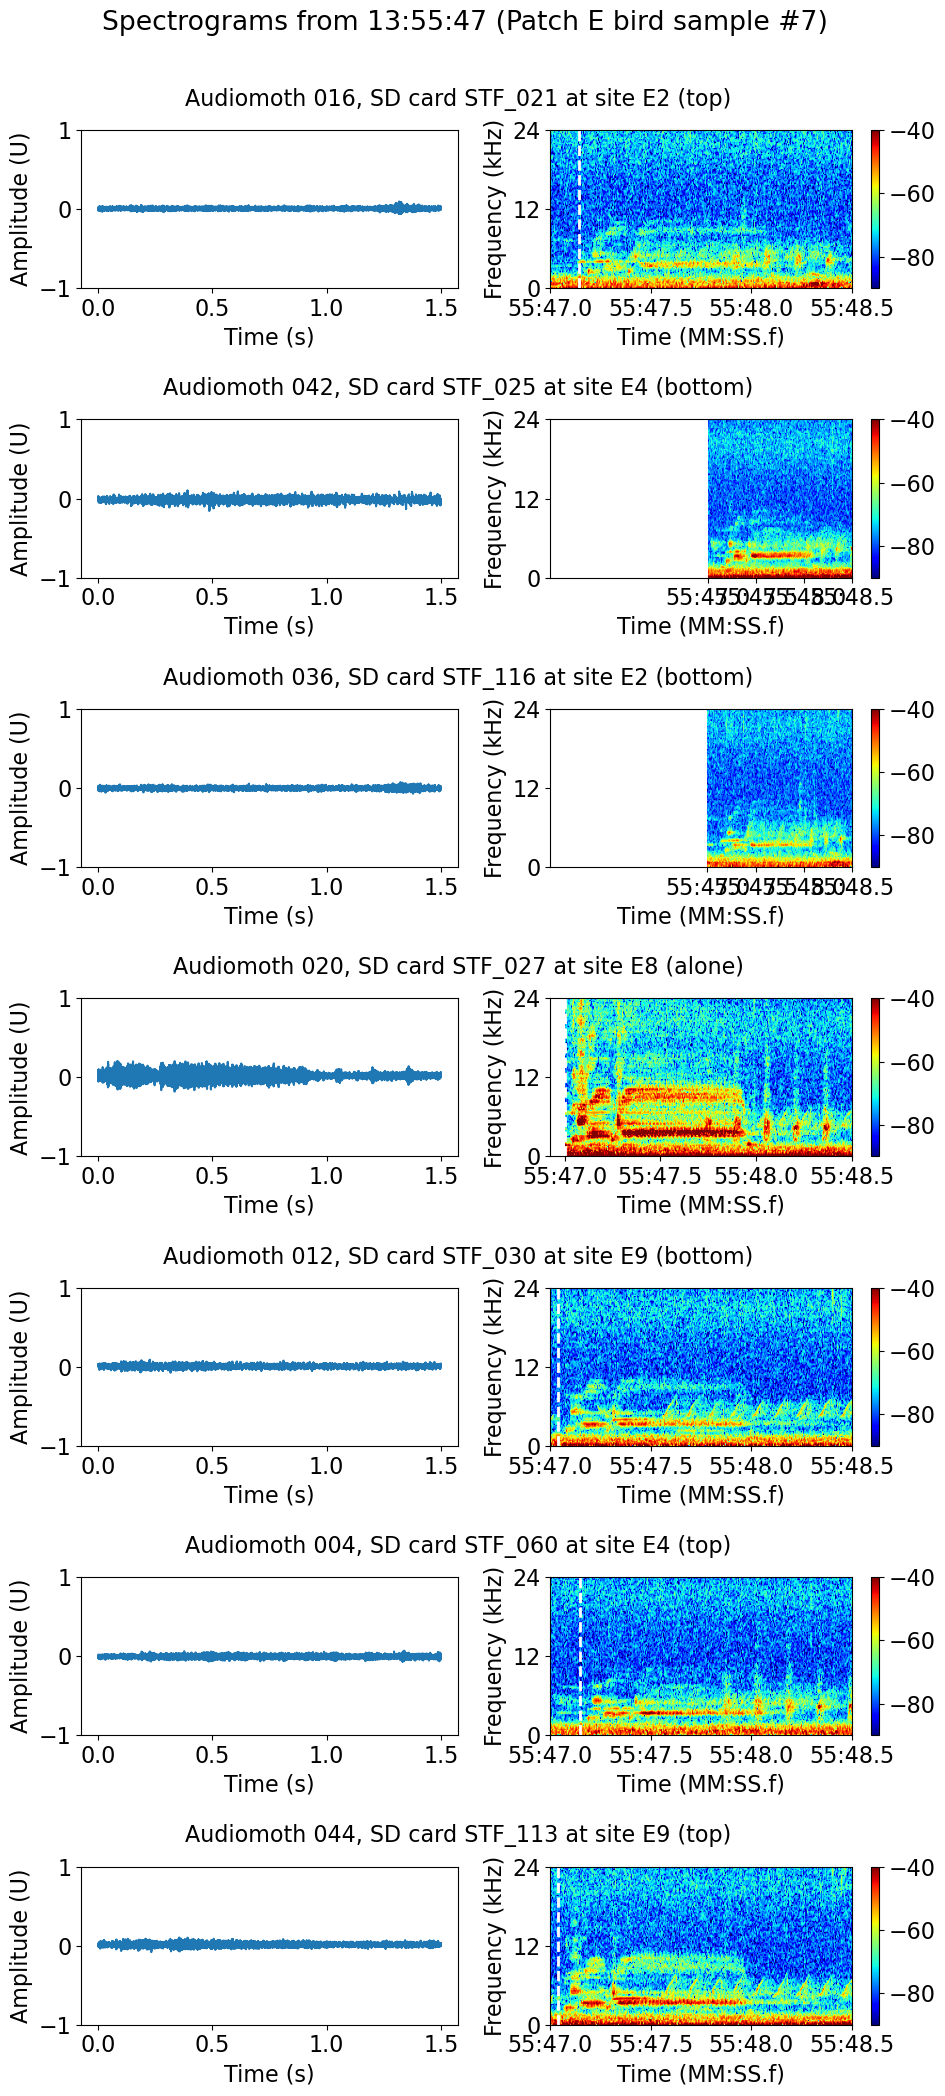

Playback at 13:55:47 localized to [[ 35.82425222 -46.00348037  57.04330898]]


In [23]:
%matplotlib inline
recording_start_dt_values = [dt.datetime(2026, 6, 4, 20, 53, 30, 0), dt.datetime(2026, 6, 4, 20, 55, 18, 500000), 
                             dt.datetime(2026, 6, 4, 20, 55, 47, 0), dt.datetime(2026, 6, 4, 20, 56, 33, 200000),
                             dt.datetime(2026, 6, 4, 20, 57, 13, 200000)]

all_playbacks_source_locs = np.zeros((len(recording_start_dt_values[2:3]), 3))
all_highpassed_audio_segments = []
for ind, recording_start_dt in enumerate(recording_start_dt_values[2:3]):
    recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
    SAMPLERATE = 192000

    highpassed_audio_segments = dict()
    audio_segments = dict()
    for example_wav_file in valid_sync_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHE.keys():
            # if recording_start_dt >  dt.datetime(2026, 6, 4, 20, 56, 12, 0):
            #     example_wav_file_dt = dt.datetime.strptime(example_wav_file.name.split('_SYNC')[0], '%Y%m%d_%H%M%S')
            #     example_wav_file = Path(str(example_wav_file).replace('_SYNC', ''))
            # else:
            example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S_PYTHON_SYNC.WAV')
            samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
            recorded_audio = sf.SoundFile(example_wav_file)
            read_offset = samples_until_recording_start
            read_duration_in_secs = 1.5
            recorded_audio.seek(int(SAMPLERATE*read_offset))
            audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
            audio_segments[wav_AUDIOMOTH] = audio_seg
            highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 2000)
            highpassed_audio_segments[wav_AUDIOMOTH] = audio_seg
    all_highpassed_audio_segments += [highpassed_audio_segments]

    template_highpassed_signal = highpassed_audio_segments['020']
    fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

    threshold = 0.03
    first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
    last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
    relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

    ax = ax_all[0]
    ax.plot(template_highpassed_signal)
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')
    ax.set_ylim(-0.1, 0.1)

    ax = ax_all[1]
    ax.plot(template_highpassed_signal)
    ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
    ax.axhline(y=threshold, linestyle='dashed', color='k')
    ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
    ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')
    ax.set_ylim(-0.1, 0.1)

    fig.tight_layout()
    plt.show()

    fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHE), 2, figsize=(10, 3*len(AUDIOMOTH_AT_PATCHE)))
    plt.rcParams.update({'font.size': 16})
    fig.suptitle(f'Spectrograms from {recording_start_string} (Patch E bird sample #7)', y=1.0)
    i = 0
    time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHE))
    time_delay_in_seconds_dictionary = dict()
    time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHE))
    time_delay_in_seconds_highpassed_dictionary = dict()
    for example_wav_file in valid_sync_wav_files:
        wav_SD_card = example_wav_file.parts[-2]
        wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
        if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHE.keys():

            highpassed_audio_seg = highpassed_audio_segments[wav_AUDIOMOTH]

            signal1 = highpassed_audio_seg
            signal2 = relevant_template_highpassed_signal
            cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
            lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
            time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed

            vmax = -40
            vmin = -90

            audio_features = dict()
            audio_features['audio_seg'] = highpassed_audio_seg
            audio_features['sample_rate'] = SAMPLERATE
            audio_features['start'] = read_offset
            audio_features['duration'] = read_duration_in_secs

            spec_features = dict()
            spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
            spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
            spec_features['vmin'] = vmin
            spec_features['vmax'] = vmax

            audio_seg = audio_features['audio_seg']
            fs = audio_features['sample_rate']
            start = audio_features['start']
            duration = audio_features['duration']

            vmax = spec_features['vmax']
            vmin = spec_features['vmin']
            cmap = spec_features['cmap']
            nfft = spec_features['NFFT']


            ax = ax_all[i, 1]
            spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
            ax.axvline(x=time_delay_in_seconds_highpassed*(fs/2), color='w', linestyle='dashed', linewidth=2)
            ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
            ax.set_ylim(0, FREQ_UPPER_LIM)
            times = []
            for s in np.linspace(0, duration, 4):
                times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
            ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 4), labels=times, rotation=0)
            fig.colorbar(im, ax=ax)
            ax.set_ylabel("Frequency (kHz)")
            ax.set_xlabel("Time (MM:SS.f)") 

            ax = ax_all[i, 0]
            ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", x=1, y=1.1, fontsize=16)
            ax.plot(np.linspace(0, read_duration_in_secs, int(read_duration_in_secs*fs)), audio_seg)
            ax.set_ylim(-1, 1)
            ax.set_ylabel('Amplitude (U)')
            ax.set_xlabel("Time (s)") 

            i += 1


    fig.tight_layout()
    plt.show()
    t_delay_ref_to_selected_channel = time_delay_in_seconds_highpassed_dictionary['016']
    time_delay_mics_to_selected_ref_channel_temp = np.array([time_delay_in_seconds_highpassed_dictionary['004'],
                                                            time_delay_in_seconds_highpassed_dictionary['020'],
                                                            time_delay_in_seconds_highpassed_dictionary['044'],
                                                            time_delay_in_seconds_highpassed_dictionary['016']])
    IND_OF_SELECTED_CHANNEL = 3
    SOUND_SPEED_AIR = 343
    time_delay_mics_to_selected_ref_channel = (time_delay_mics_to_selected_ref_channel_temp) - (t_delay_ref_to_selected_channel)

    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
    num_noise = 1000

    A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
    wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
    xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)

    source_locs = xs[:,0].reshape((1,3))
    all_playbacks_source_locs[ind] = source_locs
    print(f"Playback at {recording_start_string} localized to {source_locs}")

In [26]:
all_highpassed_audio_segments[0]['020']

array([0.03637695, 0.03543091, 0.03491211, ..., 0.05606079, 0.0567627 ,
       0.05807495])

In [28]:
output_path = "Audiomoth_020_highpassed.wav"

sf.write(
    output_path,
    all_highpassed_audio_segments[0]['020'],
    SAMPLERATE,
    subtype="PCM_16",
)

print(f"Saved to: {output_path}")

Saved to: Audiomoth_020_highpassed.wav


In [27]:
from IPython.display import Audio

Audio(
    all_highpassed_audio_segments[0]['020'],
    rate=SAMPLERATE,
    normalize=True,
)

In [ ]:
example_wav_file

PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_113/20260604_203000_PYTHON_SYNC.WAV')

In [ ]:
all_playbacks_source_locs

array([[  81.82272629,  -19.06619054,   84.91085779],
       [-629.23509178, -109.35758853,  -16.56875172],
       [  35.82425222,  -46.00348037,   57.04330898],
       [  36.05895341,  -46.29393675,   57.49914538],
       [  36.50987498,  -46.61687214,   58.2076794 ]])

In [ ]:
UBNA_ARRAY_MIC_LOCS = np.vstack([A_locs_mat_tdoa_meters, ref_A_loc_meters])
UBNA_ARRAY_MIC_LOCS

array([[ 49.10130981,  11.73724225],
       [ 49.72571837, -44.16909586],
       [ 18.30907842, -61.46608445],
       [  0.        ,   0.        ]])

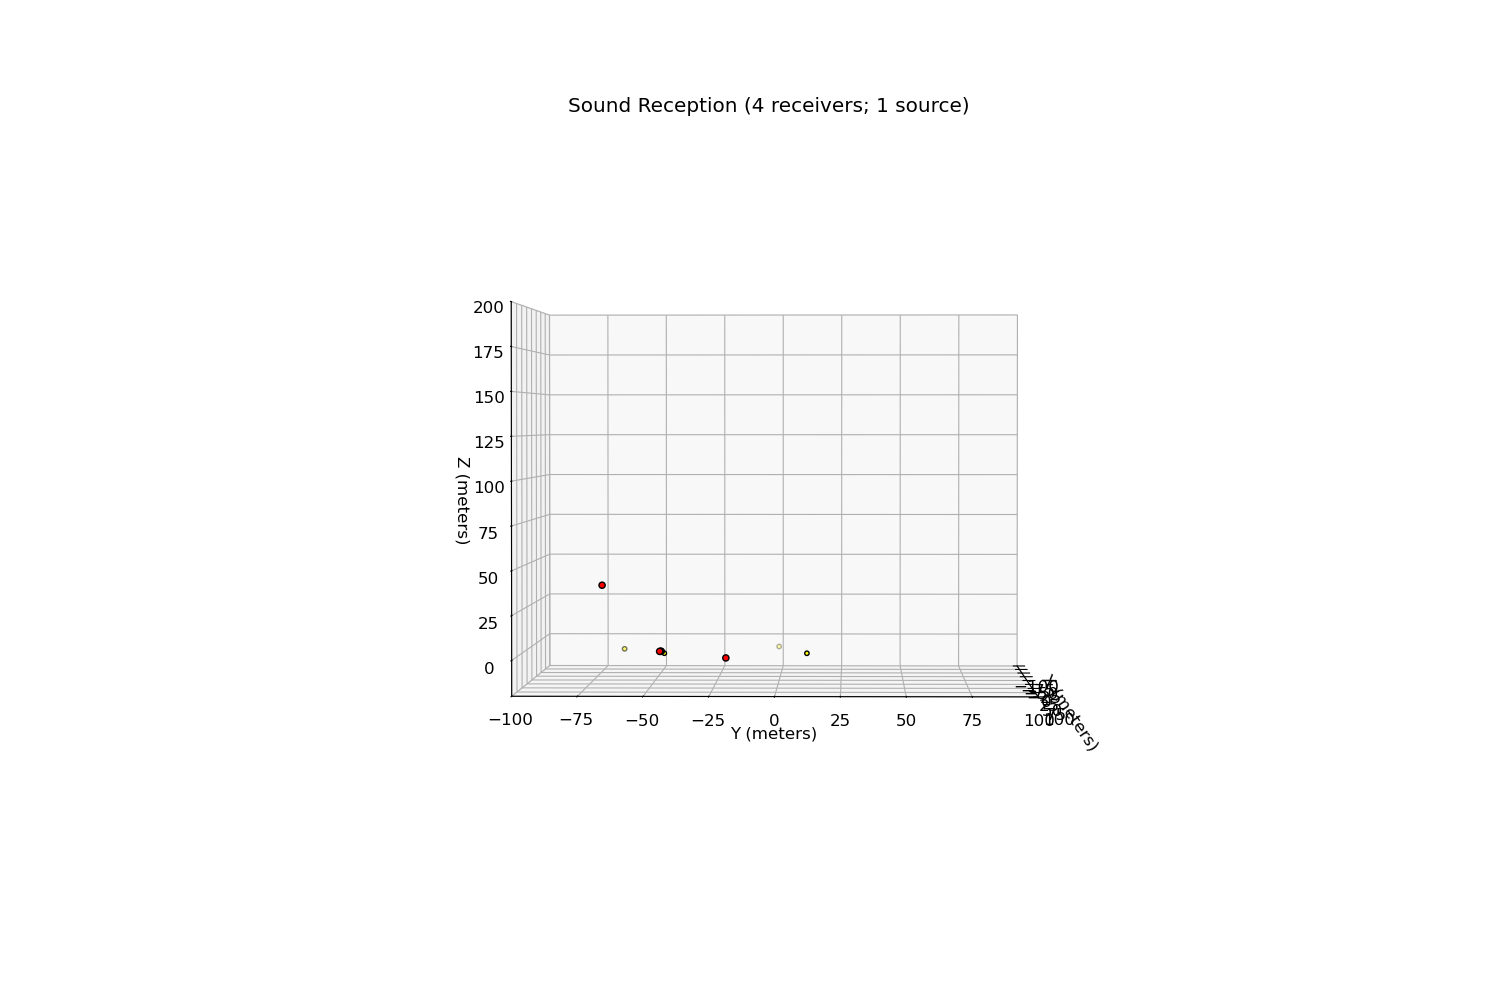

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib widget
fig = plt.figure(figsize=(15, 10))
plt.rcParams.update({'font.size':12})
map_ax_3d = fig.add_subplot(projection='3d')
POINT_SIZE = 40
GRID_SIZE = 200
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
# rN_z = UBNA_ARRAY_MIC_LOCS[:,2]

map_ax_3d.scatter(rN_x, rN_y, 0, s=10, color='yellow', edgecolor='k', zorder=1)
map_ax_3d.scatter(all_playbacks_source_locs[:,0], 
                  all_playbacks_source_locs[:,1], 0, color='r', edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
map_ax_3d.set_xlabel("X (meters)")
map_ax_3d.set_ylabel("Y (meters)")
map_ax_3d.set_zlabel("Z (meters)")
map_ax_3d.set_title(f"Sound Reception ({int(NUM_NONREFCHANNELS+1)} receivers; 1 source)")
map_ax_3d.view_init(elev=1, azim=1)

plt.show()

In [ ]:
def xy_m_to_latlon(ref_lat, ref_lon, x_east_m, y_north_m):
    """Convert local east/north offsets in meters to [latitude, longitude]."""
    R = 6_371_000  # same value used by latlon_delta_xy_m

    lat = ref_lat + np.degrees(y_north_m / R)
    mean_lat = (ref_lat + lat) / 2

    lon = ref_lon + np.degrees(
        x_east_m / (R * np.cos(np.radians(mean_lat)))
    )

    return [lat, lon]


# A7 is the (0, 0) reference microphone.
playback_latlons = [
    xy_m_to_latlon(
        ref_A_loc[0],
        ref_A_loc[1],
        x_east_m=source[0],
        y_north_m=source[1],
    )
    for source in all_playbacks_source_locs
]

In [ ]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=18,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(16, 16),
        icon_anchor=(8, 8),
        html='<div style="font-size: 16px; font-weight: bold; color: black; '
             'line-height: 16px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=5,
        color="black",
        weight=1,
        fill=True,
        fill_color="cyan",
        fill_opacity=1,
        tooltip=folium.Tooltip(
            (
                f"Playback {i}<br>"
                f"East: {x_east:.2f} m<br>"
                f"North: {y_north:.2f} m"
            ),
            sticky=True,
        )).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 14px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="
            display: inline-block;
            width: 18px;
            margin-right: 8px;
            color: black;
            font-size: 18px;
            font-weight: bold;
            text-align: center;
        ">X</span>
        <span>Microphone</span>
    </div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: cyan;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>Playback test #4 localization</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

map_name = map.get_name()

view_display = folium.Element(f"""
<script>
document.addEventListener("DOMContentLoaded", function () {{
    const leafletMap = {map_name};

    const viewBox = L.control({{position: "topright"}});

    viewBox.onAdd = function () {{
        this._div = L.DomUtil.create("div", "current-view-box");
        this._div.style.backgroundColor = "white";
        this._div.style.padding = "8px";
        this._div.style.border = "1px solid #777";
        this._div.style.borderRadius = "4px";
        this._div.style.fontSize = "12px";
        this.update();
        return this._div;
    }};

    viewBox.update = function () {{
        const center = leafletMap.getCenter();
        const zoom = leafletMap.getZoom();

        this._div.innerHTML =
            "<b>Current view</b><br>" +
            "Latitude: " + center.lat.toFixed(8) + "<br>" +
            "Longitude: " + center.lng.toFixed(8) + "<br>" +
            "Zoom: " + zoom;
    }};

    viewBox.addTo(leafletMap);

    leafletMap.on("moveend zoomend", function () {{
        viewBox.update();
    }});
}});
</script>
""")

map.get_root().html.add_child(view_display)

map

In [ ]:
AUDIOMOTH_AT_PATCHE

{'016': 'E2 (top)',
 '036': 'E2 (bottom)',
 '004': 'E4 (top)',
 '042': 'E4 (bottom)',
 '020': 'E8 (alone)',
 '044': 'E9 (top)',
 '012': 'E9 (bottom)'}

In [ ]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=18,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

folium.TileLayer(
    tiles=(
        "https://gismaps.kingcounty.gov/arcgis/rest/services/"
        "BaseMaps/KingCo_Aerial_2025/MapServer/tile/{z}/{y}/{x}"
    ),
    attr="EagleView Technologies, Inc., King County",
    name="King County Aerial 2025",
    max_native_zoom=20,
    max_zoom=21,
).add_to(map)

folium.LayerControl(position="topright").add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(40, 40),
        icon_anchor=(20, 20),
        html='<div style="font-size: 32px; font-weight: bold; color: yellow; '
            'line-height: 40px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=6,
        color="black",
        weight=1,
        fill=True,
        fill_color="orange",
        fill_opacity=1,
        tooltip=folium.Tooltip(
            (
                f"Playback {i}<br>"
                f"East: {x_east:.2f} m<br>"
                f"North: {y_north:.2f} m"
            ),
            sticky=True,
        )).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 60px;
    left: 40px;
    z-index: 9999;
    background-color: gray;
    color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 18px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: orange;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>RWB localization from synced files</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

scale_css = """<style>
.leaflet-control-scale-line {
    font-size: 16px !important;
}
</style>"""

map.get_root().header.add_child(folium.Element(scale_css))
map

map

In [ ]:
from folium.plugins import MeasureControl

map = folium.Map(
    location=[47.65482429333334, -122.29547748000003],
    zoom_start=21,
    control_scale=True,
    max_zoom=24,
    tiles=None,
)

folium.TileLayer(
    tiles="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
    attr="© OpenStreetMap contributors",
    name="OpenStreetMap",
    max_native_zoom=19,
    max_zoom=24,
).add_to(map)

folium.TileLayer(
    tiles=(
        "https://gismaps.kingcounty.gov/arcgis/rest/services/"
        "BaseMaps/KingCo_Aerial_2025/MapServer/tile/{z}/{y}/{x}"
    ),
    attr="EagleView Technologies, Inc., King County",
    name="King County Aerial 2025",
    max_native_zoom=20,
    max_zoom=21,
).add_to(map)

folium.LayerControl(position="topright").add_to(map)

marker_locations = [("Microphone (E2)", A_locs_mat_tdoa[0,:2].tolist()),
                    ("Microphone (E4)", A_locs_mat_tdoa[1,:2].tolist()),
                    ("Microphone (E8)", ref_A_loc[:2].tolist()),
                    ("Microphone (E9)", A_locs_mat_tdoa[2,:2].tolist())]

for name, location in marker_locations:
    coordinate_label = f"{name}"

    x_icon = folium.DivIcon(
        icon_size=(40, 40),
        icon_anchor=(20, 20),
        html='<div style="font-size: 32px; font-weight: bold; color: yellow; '
            'line-height: 40px; text-align: center;">X</div>',
    )

    folium.Marker(location=location, icon=x_icon, 
                  tooltip=folium.Tooltip(
                            coordinate_label,
                            direction="right",
                            offset=(8, 0))).add_to(map)
    
for i, (location, source) in enumerate(zip(playback_latlons, all_playbacks_source_locs), start=1):
    x_east, y_north = source[:2]

    folium.CircleMarker(
        location=location,
        radius=6,
        color="black",
        weight=1,
        fill=True,
        fill_color="cyan",
        fill_opacity=1).add_to(map)

# The ruler button measures a line drawn between any points on the map.
MeasureControl(position="topleft", primary_length_unit="meters", secondary_length_unit="feet").add_to(map)
legend_html = """
<div style="
    position: fixed;
    bottom: 60px;
    left: 40px;
    z-index: 9999;
    background-color: gray;
    color: white;
    border: 2px solid #777;
    border-radius: 5px;
    padding: 10px 14px;
    font-size: 18px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
">
    <div style="font-weight: bold; margin-bottom: 8px;">Legend</div>

    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="
            display: inline-block;
            width: 18px;
            margin-right: 8px;
            color: yellow;
            font-size: 18px;
            font-weight: bold;
            text-align: center;
        ">X</span>
        <span>Microphone</span>
    </div>

    <div style="display: flex; align-items: center;">
        <span style="
            display: inline-block;
            width: 10px;
            height: 10px;
            margin-left: 4px;
            margin-right: 12px;
            background-color: cyan;
            border: 1px solid black;
            border-radius: 50%;
        "></span>
        <span>Playback test #4 localization</span>
    </div>
</div>
"""

map.get_root().html.add_child(folium.Element(legend_html))

scale_css = """<style>
.leaflet-control-scale-line {
    font-size: 16px !important;
}
</style>"""

map.get_root().header.add_child(folium.Element(scale_css))
map

map